In [47]:
%load_ext autoreload
%autoreload 2

# Define autroreload so that it doesn't cause pain in the ass when we change the functions and run this notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
# Define the system paths
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parents[3] # Gets the GitHub repo folder
print(project_root)
sys.path.append(str(project_root))

C:\SenkDosya\Projects\FINCH-Science_SyntheticData


In [49]:
from defs.diffusion.data_augmentation import *

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [51]:
from defs.diffusion.training_defs import *

# Data handle:
data_handle = str(project_root)+'\data\simpler_data_rwc.csv'

# cfg_train:
cfg_train = {
    'cfg_loader': {
        'test': 23, 't_batch': 2, 'validate': 4, 'epoch': 50
    },
    'range': [900, 1700],
    'device': device,
    'tot_samples': 1723
}

# Figure out the data

# First, we will pre-process and parse all the data
# Get the spectral range that we want to use
spec_range = cfg_train.get('range', [400, 2490])

# Parse the csv into sub-parts we want to use
spectra, abundances, names, indices = get_vals(data_handle=data_handle, spec_range=spec_range, normalize=False)

# Generate the hyperspectral dataset
ds = HyperSpectralDataset(spectra=spectra, abundances=abundances, names=names, indices=indices)

# Dataload the giant dataset into train, test, validation datasets
cfg_loader = cfg_train.get(
    'cfg_loader', {'test': 23, 't_batch': 1, 'validate': 4, 'epoch': 50}
) # Get the configs for the loader first

# Get the dataloaded datasets
dataloaders= get_dataloaders(ds, cfg_loader=cfg_loader)

train_dl, test_dl, val_dl = dataloaders

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Ege Artan\AppData\Local\Temp\ipykernel_6616\3151529550.py:4: SyntaxWarning: invalid escape sequence '\d'
  data_handle = str(project_root)+'\data\simpler_data_rwc.csv'


In [52]:
batch = next(iter(train_dl))
x0, abundances, name, orig_index = batch['spectrum'], batch['abundances'], batch['names'], batch['orig_index']

In [53]:
augmenter = SpectralAugmentation(jitter_scale=0.001)
x0_aug = augmenter(x0)

tensor([[0.2033, 0.2044, 0.2053, 0.2071, 0.2036, 0.2037, 0.2014, 0.2002, 0.2004,
         0.2019, 0.2045, 0.2061, 0.2088, 0.2127, 0.2158, 0.2189, 0.2218, 0.2241,
         0.2258, 0.2268, 0.2272, 0.2283, 0.2273, 0.2226, 0.2165, 0.2060, 0.1990,
         0.1960, 0.1948, 0.1932, 0.1932, 0.1947, 0.1987, 0.2032, 0.2074, 0.2107,
         0.2135, 0.2151, 0.2167, 0.2167, 0.2157, 0.2123, 0.2064, 0.1987, 0.1900,
         0.1856, 0.1822, 0.1641, 0.1520, 0.1171, 0.1045, 0.0846, 0.0767, 0.0727,
         0.0700, 0.0687, 0.0691, 0.0700, 0.0722, 0.0752, 0.0783, 0.0818, 0.0854,
         0.0887, 0.0918, 0.0948, 0.0978, 0.1006, 0.1035, 0.1063, 0.1091, 0.1122,
         0.1146, 0.1169, 0.1185, 0.1188, 0.1180, 0.1174, 0.1171, 0.1158, 0.1137],
        [0.3628, 0.3663, 0.3688, 0.3722, 0.3758, 0.3756, 0.3718, 0.3692, 0.3703,
         0.3722, 0.3755, 0.3820, 0.3880, 0.3941, 0.3994, 0.4048, 0.4101, 0.4141,
         0.4185, 0.4224, 0.4261, 0.4296, 0.4390, 0.4406, 0.4294, 0.4151, 0.4052,
         0.4009, 0.4013, 0.

[]

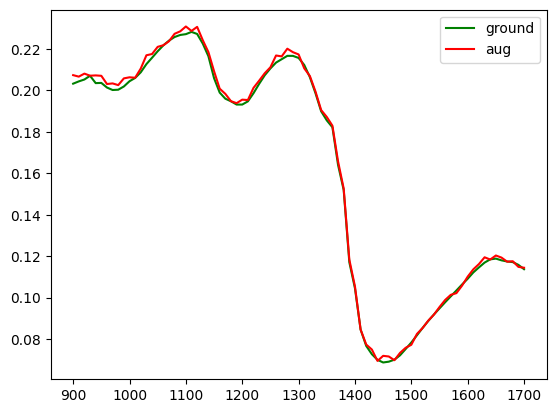

In [54]:
import matplotlib.pyplot as plt

wavelengths = torch.arange(900, 1710, 10)

print(x0)

plt.plot(wavelengths, x0[0], 'g-', label='ground')
plt.plot(wavelengths, x0_aug[0], 'r-', label='aug')
plt.legend()
plt.plot()